#RSS

## Importing System Libraries & Mounting Drive


In [ ]:
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# from IPython.display import Image
import h5py
import glob
import shutil # Used in delete_path()
# import subprocess

In [ ]:
#Mounting Google Drive
from google.colab import drive
# !rm -rf drive

drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
def delete_path(path_to_delete):
  if os.path.exists(path_to_delete) and os.path.isdir(path_to_delete):
    try:
      # Force delete the directory and all its contents
      shutil.rmtree(path_to_delete)
      print(f"Directory '{path_to_delete}' and all its contents have been deleted.")
    except Exception as e:
      print(f"Error while deleting the directory: {e}")
  else:
    print(f"The directory '{path_to_delete}' does not exist.")

def create_path(path_to_create):
  if not os.path.exists(path_to_create):
    os.makedirs(path_to_create)
    print(f"Path Created!!! Put the '.h5' files in the specific place: {path_to_create}")
  else:
    print("Path Already Exists!!")

## Helper Functions

In [ ]:
# Get a list of all .h5 files in the directory
def get_file_list(h5_path):
    h5_files = glob.glob(os.path.join(h5_path, "*.h5"))
    ll=[]

    for h5_file in h5_files:
      temp=h5_file.replace(h5_path,"")
      temp=temp.replace(".h5","")
      ll.append(temp)
    return ll


#Getting User Input on Image
def get_user_input(ll):
    for index,tt in enumerate(ll):
      print(index,":\t", tt)
    print("\nEnter the index of the file name from the above list: ")
    ins = input()
    return int(ins)


#Extracting Volume K Space for specified Image.
def get_volume_kspace(h5_file_name):
    hf= h5py.File(h5_file_name)
    volume_kspace = hf['kspace']
    return volume_kspace


def process_h5_file(h5_file_name, slice_no):
    h5_file_path=h5_path+h5_file_name+".h5"
    h5_file_cfl_dict=cfl_path+h5_file_name+"/"
    create_path(h5_file_cfl_dict)

    #Getting the Volume K Space Data
    volume_kspace = get_volume_kspace(h5_file_path)
    print("H5 five file size:",volume_kspace.shape)
    slice_nos=volume_kspace.shape[0]
    print("No of slices are:",slice_nos)
    print("*****\tFor Slice No.: ",slice_no,"\t*********")

    # Extracting Slice from volume K Space
    slice_kspace = volume_kspace[slice_no]
    print("Slice K-Space size: ",slice_kspace.shape)

### Test

In [ ]:
h5_path_for_test = "/content/"
h5_file_name_for_test = "file_brain_AXT2_210_6001944"
h5_file_path_for_test = h5_path_for_test+h5_file_name_for_test+".h5"
hf_test = h5py.File(h5_file_path_for_test)

list(hf_test.keys())


OSError: Unable to synchronously open file (truncated file: eof = 294649856, sblock->base_addr = 0, stored_eof = 788021272)

## K-space plot

In [ ]:
def plot_kspace(volume_kspace, output_root, cmap="gray"):
  num_slices, num_coils = volume_kspace.shape[:2]

  for slice_idx in range(num_slices):
    slice_dir = os.path.join(output_root, f"slice_{slice_idx+1:03d}")
    os.makedirs(slice_dir, exist_ok=True)

    print(f"Processing Slice {slice_idx}")

    curr_slice = volume_kspace[slice_idx][()]

    for coil_idx in range(num_coils):
      kspace_mag = np.abs(curr_slice[coil_idx])

      # print(kspace_mag)
      plt.figure()
      plt.imshow(kspace_mag, cmap=cmap)
      plt.axis("off")
      plt.title(f"Slice {slice_idx} | Coil {coil_idx+1}")

      save_path = os.path.join(slice_dir, f"coil_{coil_idx+1:02d}.png")
      plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
      plt.close()

def plot_kspace_norm(volume_kspace, output_root, cmap="gray"):
  num_slices, num_coils = volume_kspace.shape[:2]

  for slice_idx in range(num_slices):
    slice_dir = os.path.join(output_root, f"slice_{slice_idx+1:03d}")
    os.makedirs(slice_dir, exist_ok=True)

    print(f"Processing Slice {slice_idx}")

    curr_slice = volume_kspace[slice_idx][()]

    for coil_idx in range(num_coils):
      kspace_mag = np.abs(curr_slice[coil_idx])

      kspace_lnor = np.log(kspace_mag + 1e-9)
      kspace_nor = (kspace_lnor - kspace_lnor.min()) / (
          kspace_lnor.max() - kspace_lnor.min() + 1e-9
      )

      # print(kspace_nor)
      plt.figure()
      plt.imshow(kspace_nor, cmap=cmap)
      plt.axis("off")
      plt.title(f"Slice {slice_idx} | Coil {coil_idx+1}")

      save_path = os.path.join(slice_dir, f"coil_{coil_idx+1:02d}.png")
      plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
      plt.close()


### Test: K-space visualization

In [ ]:
plot_kspace(hf_test['kspace'], "content/test_out/kspace/")
plot_kspace_norm(hf_test['kspace'], "content/test_out/kspace_norm/")

Processing Slice 0
Processing Slice 1
Processing Slice 2
Processing Slice 3
Processing Slice 4
Processing Slice 5
Processing Slice 6
Processing Slice 7
Processing Slice 8
Processing Slice 9
Processing Slice 10
Processing Slice 11
Processing Slice 12
Processing Slice 13
Processing Slice 14
Processing Slice 15
Processing Slice 0
Processing Slice 1
Processing Slice 2
Processing Slice 3
Processing Slice 4
Processing Slice 5
Processing Slice 6
Processing Slice 7
Processing Slice 8
Processing Slice 9
Processing Slice 10
Processing Slice 11
Processing Slice 12
Processing Slice 13
Processing Slice 14
Processing Slice 15


## Image Plot

In [ ]:
def center_crop(img, crop_h=396, crop_w=396):
    """
    Center crop a 2D image.

    Args:
        img (np.ndarray): 2D image (H, W)
        crop_h (int): crop height
        crop_w (int): crop width

    Returns:
        np.ndarray: Center-cropped image
    """
    h, w = img.shape
    start_h = (h - crop_h) // 2
    start_w = (w - crop_w) // 2

    return img[start_h:start_h + crop_h, start_w:start_w + crop_w]


In [ ]:
def reconstruct_slice_kspace(slice_kspace):
    """
    Reconstructs a single slice from multi-coil k-space using
    IFFT + Root Sum of Squares (RSS)

    Args:
        slice_kspace (np.ndarray):
            Shape -> (num_coils, H, W)

    Returns:
        np.ndarray:
            Reconstructed magnitude image (H, W)
    """
    num_coils = slice_kspace.shape[0]
    coil_images = []

    for i in range(num_coils):
        img = np.fft.ifft2(slice_kspace[i])
        img = np.fft.fftshift(img)
        coil_images.append(img)

    coil_images = np.array(coil_images)

    # Root Sum of Squares
    combined_image = np.sqrt(np.sum(np.abs(coil_images) ** 2, axis=0))

    return combined_image, coil_images


### Test: Reconstruction of slice (without crop)

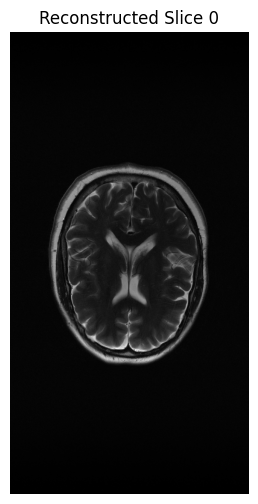

In [ ]:
recon_image = reconstruct_slice_kspace(hf_test['kspace'][0])[0]

# Normalize for visualization
recon_norm = recon_image / (np.max(recon_image) + 1e-9)
# Plot (no display)
plt.figure(figsize=(6, 6))
plt.imshow(recon_norm, cmap=cm.gray)
plt.axis("off")
plt.title(f"Reconstructed Slice {0}")
plt.show()

### Test: Cropped reconstruction of slice

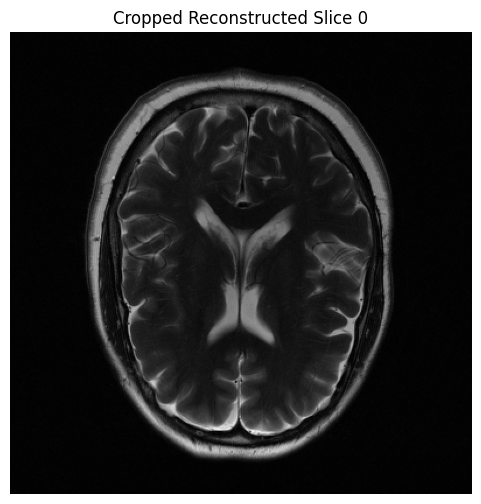

In [ ]:
recon_image = reconstruct_slice_kspace(hf_test['kspace'][0])[0]

crop_recon_image = center_crop(recon_image)

# Normalize for visualization
recon_norm = crop_recon_image / (np.max(crop_recon_image) + 1e-9)
# Plot (no display)
plt.figure(figsize=(6, 6))
plt.imshow(recon_norm, cmap=cm.gray)
plt.axis("off")
plt.title(f"Cropped Reconstructed Slice {0}")
plt.show()

### Test: Reconstruction of cropped slice

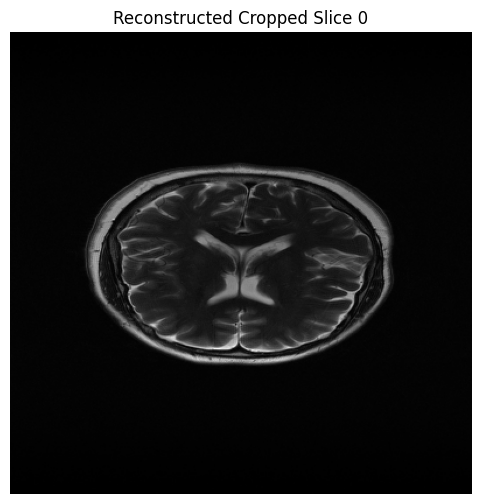

In [ ]:
test_slice = hf_test['kspace'][0][()]
num_coils = test_slice.shape[0]
final_slice = np.empty((num_coils, 396, 396), dtype=np.complex64)
for coil_idx in range(num_coils):
    final_slice[coil_idx] = center_crop(test_slice[coil_idx])

recon_image = reconstruct_slice_kspace(final_slice)[0]

crop_recon_image = center_crop(recon_image)

# Normalize for visualization
recon_norm = crop_recon_image / (np.max(crop_recon_image) + 1e-9)
# Plot (no display)
plt.figure(figsize=(6, 6))
plt.imshow(recon_norm, cmap=cm.gray)
plt.axis("off")
plt.title(f"Reconstructed Cropped Slice {0}")
plt.show()

## Masks

In [ ]:
def generate_mask(shape, mask_type="random", **kwargs):
    nx, ny = shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    cx, cy = nx//2, ny//2
    r = np.sqrt((X-cx)**2 + (Y-cy)**2)
    r_max = min(nx, ny)//2

    if mask_type == "random":
        prob = kwargs.get("prob", 0.5)
        mask = np.random.rand(nx, ny) < prob
    elif mask_type == "gaussian":
      sigma = kwargs.get("sigma", min(nx, ny) / 4)
      pdf = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
      mask = np.random.rand(nx, ny) < pdf
    elif mask_type == "radial":
      n_spokes = kwargs.get("n_spokes", 20)
      mask = np.zeros((nx, ny), dtype=bool)
      cx, cy = nx//2, ny//2
      angles = np.linspace(0, np.pi, n_spokes, endpoint=False)
      for theta in angles:
        x = np.arange(nx) - cx
        y = np.round(np.tan(theta) * x).astype(int)
        valid = (y + cy >= 0) & (y + cy < ny)
        mask[x[valid]+cx, y[valid]+cy] = True
    elif mask_type == "spiral":
      # simple Archimedean spiral sampling
      n_arms = kwargs.get("n_arms", 5)
      mask = np.zeros((nx, ny), dtype=bool)
      cx, cy = nx//2, ny//2
      r_max = min(cx, cy)
      theta = np.linspace(0, 4*np.pi, nx)
      for i in range(n_arms):
        x = (cx + (r_max * theta/(4*np.pi)) * np.cos(theta + i*2*np.pi/n_arms)).astype(int)
        y = (cy + (r_max * theta/(4*np.pi)) * np.sin(theta + i*2*np.pi/n_arms)).astype(int)
        valid = (x >= 0) & (x < nx) & (y >= 0) & (y < ny)
        mask[x[valid], y[valid]] = True
    elif mask_type == "rectilinear_x":
      factor_x = kwargs.get("factor_x", 4)
      mask = np.zeros((nx, ny), dtype=bool)
      # Takes every 'factor_x' row, but keeps all columns in that row
      mask[::factor_x, :] = True
    elif mask_type == "rectilinear_y":
      factor_y = kwargs.get("factor_y", 4)
      mask = np.zeros((nx, ny), dtype=bool)
      # Takes every 'factor_y' column, but keeps all rows in that column
      mask[:, ::factor_y] = True
    elif mask_type == "checkerboard":
      mask = np.indices((nx, ny)).sum(axis=0) % 2 == 0
    elif mask_type == "inv_checkerboard":
      mask = !(np.indices((nx, ny)).sum(axis=0) % 2 == 0)
    else:
        raise ValueError(f"Unknown mask_type: {mask_type}")

    return mask

In [ ]:
def get_masked_reconstruction(slice_kspace, mask_type="random", **kwargs):
    """
    Applies a specified mask to a multi-coil k-space slice and reconstructs it.

    Args:
        slice_kspace (np.ndarray): Shape (num_coils, H, W)
        mask_type (str): Type of mask to generate.
        **kwargs: Arguments passed to generate_mask (e.g., prob, sigma, n_arms).

    Returns:
        tuple: (combined_image, coil_images, mask)
            - combined_image: RSS reconstructed magnitude image (H, W)
            - coil_images: Individual complex coil images (num_coils, H, W)
            - mask: The boolean mask applied to the k-space (H, W)
    """
    num_coils, nx, ny = slice_kspace.shape

    # 1. Generate the mask ONCE for the spatial dimensions
    mask = generate_mask((nx, ny), mask_type=mask_type, **kwargs).astype(int)

    # 2. Apply the mask across all coils
    masked_slice_kspace = slice_kspace * mask

    # 3. Reconstruct the undersampled data
    combined_image, coil_images = reconstruct_slice_kspace(masked_slice_kspace)

    return combined_image, coil_images, mask

## Pipeline

In [ ]:

h5_dir = input() or r"/content/" # defaults to /content/
output_dir = input() or r"/content/out/"

print(h5_dir)
list_of_files = get_file_list(h5_dir)
print(list_of_files)

masks_list = [
    "inv_checkerboard", "checkerboard", "rectilinear_y", "rectilinear_x", "spiral",
    "radial", "gaussian", "random"
]



/content/
['file_brain_AXT2_210_6001944']


### Saving k-space data

Processing file_brain_AXT2_210_6001944
Saving normalizaed k-space plots
Processing Slice 0


Exception ignored in: <function TransformNode.set_children.<locals>.<lambda> at 0x7c400c42cea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py", line 195, in <lambda>
    self, lambda _, pop=child._parents.pop, k=id_self: pop(k))

KeyboardInterrupt: 


Processing Slice 1


TypeError: affine_transform(): incompatible function arguments. The following argument types are supported:
    1. (points: numpy.ndarray[numpy.float64], trans: trans_affine) -> object

Invoked with: [[np.float64(0.0), np.float64(0.0)], [np.float64(6.4), np.float64(0.0)], [np.float64(0.0), np.float64(4.8)], [np.float64(6.4), np.float64(4.8)]], array([[100.,   0.,   0.],
       [  0., 100.,   0.],
       [  0.,   0.,   1.]])

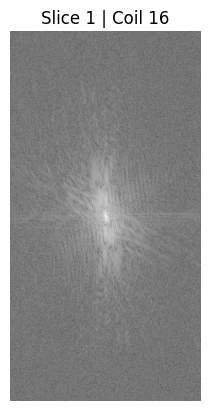

In [ ]:
for file_idx in range(len(list_of_files)):
  file_name = list_of_files[file_idx]
  print(f"Processing {file_name}")

  print("Saving normalizaed k-space plots")
  kspace_data = get_volume_kspace(os.path.join(h5_dir, file_name+".h5"))
  plot_kspace_norm(kspace_data, os.path.join(output_dir, "kspace_norm", file_name))

### Saving reconstructed images and the coils without mask

In [ ]:
for file_idx in range(len(list_of_files)):
  file_name = list_of_files[file_idx]
  print(f"Processing {file_name}")

  save_dir = os.path.join(output_dir, "crop_recon", file_name)
  os.makedirs(save_dir, exist_ok=True)

  kspace_data = get_volume_kspace(os.path.join(h5_dir, file_name+".h5"))

  for slice_idx in range(kspace_data.shape[0]):
    save_dir_coils = os.path.join(save_dir, f"slice_{slice_idx+1:03d}")
    os.makedirs(save_dir_coils, exist_ok=True)

    print(f"Processing Slice {slice_idx:03d}")
    recon_image, coil_images = reconstruct_slice_kspace(kspace_data[slice_idx])

    for coil_idx in range(len(coil_images)):
      coil_img = np.abs(coil_images[coil_idx])
      crop_coil = center_crop(coil_img)
      norm_coil = crop_coil / (np.max(crop_coil) + 1e-9)

      plt.figure()
      plt.imshow(norm_coil, cmap=cm.gray)
      plt.axis("off")
      plt.title(f"Cropped Reconstructed Coil {coil_idx+1}")

      save_path = os.path.join(save_dir_coils, f"coil_{coil_idx+1:02d}.png")
      plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
      plt.close()

    crop_recon_image = center_crop(recon_image)

    # Normalize for visualization
    recon_norm = crop_recon_image / (np.max(crop_recon_image) + 1e-9)

    # Plot (no display)
    plt.figure()
    plt.imshow(recon_norm, cmap=cm.gray)
    plt.axis("off")
    plt.title(f"Cropped Reconstructed Slice {slice_idx+1}")

    save_path = os.path.join(save_dir, f"slice_{slice_idx+1:03d}.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

Processing file_brain_AXT2_210_6001944
Processing Slice 000
Processing Slice 001
Processing Slice 002
Processing Slice 003
Processing Slice 004
Processing Slice 005
Processing Slice 006
Processing Slice 007
Processing Slice 008
Processing Slice 009
Processing Slice 010
Processing Slice 011
Processing Slice 012
Processing Slice 013
Processing Slice 014
Processing Slice 015


### With mask

In [ ]:
for file_idx in range(len(list_of_files)):
  file_name = list_of_files[file_idx]
  print(f"Processing {file_name}")

  kspace_data = get_volume_kspace(os.path.join(h5_dir, file_name+".h5"))

  chosen_mask = "rectilinear_y"

  save_dir = os.path.join(output_dir, "with_mask", file_name, chosen_mask)
  os.makedirs(save_dir, exist_ok=True)

  for slice_idx in range(kspace_data.shape[0]):
    save_dir_coils = os.path.join(save_dir, f"slice_{slice_idx+1:03d}")
    os.makedirs(save_dir_coils, exist_ok=True)

    print(f"Processing Slice {slice_idx+1:03d}")
    recon_image, coil_images, mask = get_masked_reconstruction(kspace_data[slice_idx], chosen_mask)

    plt.figure()
    plt.imshow(mask, cmap=cm.gray)
    plt.axis("off")
    plt.title(f"Generated Mask | {chosen_mask}")

    save_path = os.path.join(save_dir, "Gen_Mask.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

    for coil_idx in range(len(coil_images)):
      coil_img = np.abs(coil_images[coil_idx])
      crop_coil = center_crop(coil_img)
      norm_coil = crop_coil / (np.max(crop_coil) + 1e-9)

      plt.figure()
      plt.imshow(norm_coil, cmap=cm.gray)
      plt.axis("off")
      plt.title(f"Cropped Recon Coil {coil_idx+1} | {chosen_mask} Mask")

      save_path = os.path.join(save_dir_coils, f"coil_{coil_idx+1:02d}.png")
      plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
      plt.close()

    crop_recon_image = center_crop(recon_image)

    # Normalize for visualization
    recon_norm = crop_recon_image / (np.max(crop_recon_image) + 1e-9)

    # Plot (no display)
    plt.figure()
    plt.imshow(recon_norm, cmap=cm.gray)
    plt.axis("off")
    plt.title(f"Cropped Reconstructed Slice {slice_idx+1}")

    save_path = os.path.join(save_dir, f"slice_{slice_idx+1:03d}.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

Processing file_brain_AXT2_210_6001944
Processing Slice 001
Processing Slice 002
Processing Slice 003
Processing Slice 004
Processing Slice 005
Processing Slice 006
Processing Slice 007
Processing Slice 008
Processing Slice 009
Processing Slice 010
Processing Slice 011
Processing Slice 012
Processing Slice 013
Processing Slice 014
Processing Slice 015
Processing Slice 016
